In [1]:
import at
from numpy import pi
import numpy as np
import matplotlib.pyplot as plt
import copy

# ------------------------------------------------------------
# Build a simple FODO cell with BPMs and correctors
# ------------------------------------------------------------

QF = at.Quadrupole("QF", 0.5, 1.2)
QD = at.Quadrupole("QD", 0.5, -1.2)
Dr = at.Drift("Dr", 0.5)
HalfDr = at.Drift("Dr2", 0.25)

Bend = at.Dipole(
    "Bend",
    1.0,
    2 * pi / 40
)

BPM = at.Monitor("BPM")
BPM = at.Monitor("BPM")


COR = at.Corrector(
    "COR",
    0.0,
    [0.0, 0.0]
)
COR= at.Corrector(
    "COR",
    0.0,
    [0.0, 0.0]
)

# ------------------------------------------------------------
# FODO cell
# ------------------------------------------------------------

FODOcell = at.Lattice(
    [
        HalfDr,
        Bend,
        Dr,

        QF,
        BPM,
        COR,

        Dr,
        Bend,
        Dr,

        QD,
        BPM,
        COR,

        HalfDr,
    ],
    name="Simple FODO cell",
    energy=1e9,
)


FODO = FODOcell * 20

print(FODO)



Lattice(<260 elements>, name='Simple FODO cell', energy=1000000000.0, particle=Particle('relativistic'), periodicity=1, beam_current=0.0, nbunch=0)


In [2]:
# ------------------------------------------------------------
# Get elements_indices
# ------------------------------------------------------------

bpm_indices = at.get_refpts(FODO, at.elements.Monitor)
cor_indices = at.get_refpts(FODO, at.elements.Corrector)
quads_indices = at.get_refpts(FODO, at.elements.Quadrupole)
qf_indices = at.get_refpts(FODO, "QF*")
qd_indices = at.get_refpts(FODO, "QD*")
dipoles_indices = at.get_refpts(FODO, at.elements.Dipole)


In [3]:
# ------------------------------------------------------------
# Fit the Tune
# ------------------------------------------------------------


at.fit_tune(FODO, qf_indices, qd_indices, [0.15, 0.75])


Fitting Tune...
Initial value [0.21993568 0.91777806]
iter# 0 Res. 1.8554910835460303e-06
iter# 1 Res. 7.129086923354e-10
iter# 2 Res. 2.6680041360826346e-13
Final value [0.1500004  0.75000033] 



Tune BEFORE errors:
  Qx = 0.150000
  Qy = 0.750000


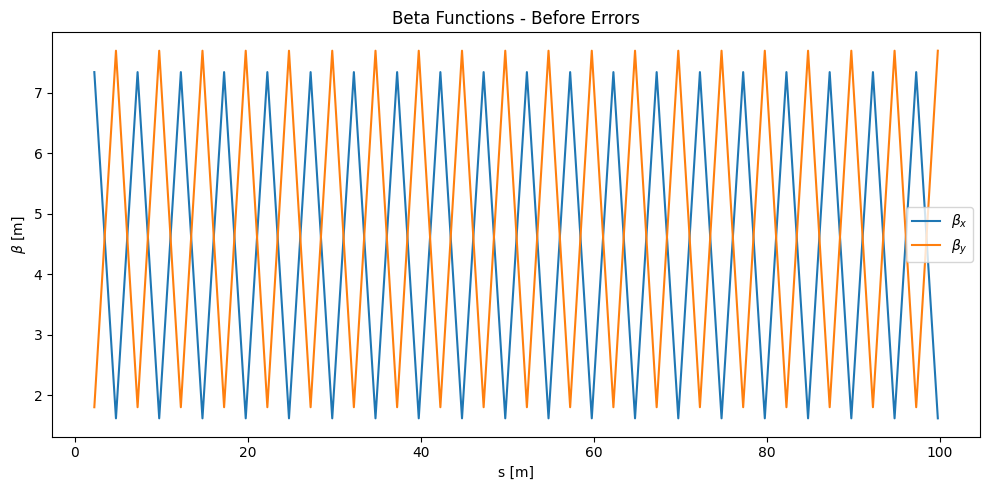

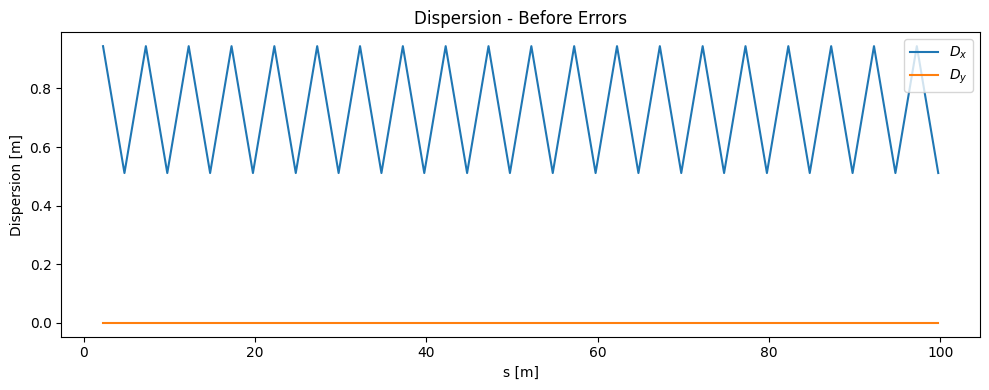

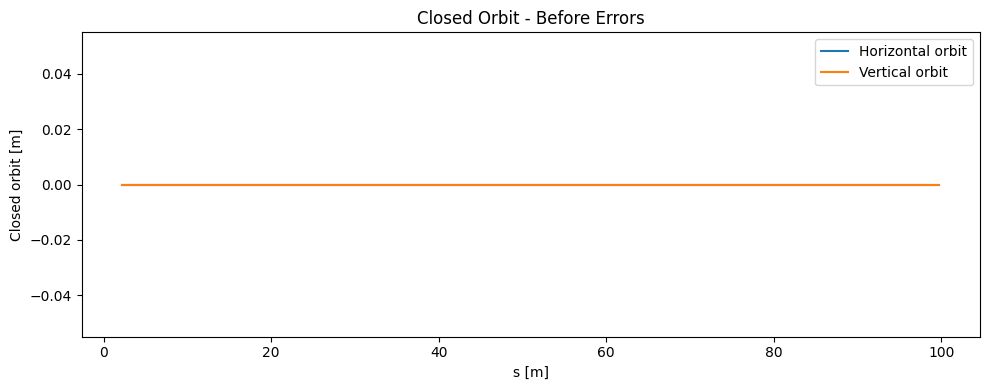

In [4]:
# ============================================================
# OPTICS BEFORE QUADRUPOLE ERRORS
# ============================================================

lindata0_before, ringdata_before, lindata_before = at.get_optics(
    FODO,
    refpts=bpm_indices
)


# ------------------------------------------------------------
# Global optics parameters
# ------------------------------------------------------------

tune_before = ringdata_before.tune

print("Tune BEFORE errors:")
print(f"  Qx = {tune_before[0]:.6f}")
print(f"  Qy = {tune_before[1]:.6f}")


# ------------------------------------------------------------
# Extract optics
# ------------------------------------------------------------

s_before = lindata_before.s_pos

beta_x_before = lindata_before.beta[:, 0]
beta_y_before = lindata_before.beta[:, 1]

disp_x_before = lindata_before.dispersion[:, 0]
disp_y_before = lindata_before.dispersion[:, 2]

x_orbit_before = lindata_before.closed_orbit[:, 0]
y_orbit_before = lindata_before.closed_orbit[:, 2]


# ------------------------------------------------------------
# Plot beta functions BEFORE
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(s_before, beta_x_before, label=r"$\beta_x$")
plt.plot(s_before, beta_y_before, label=r"$\beta_y$")

plt.xlabel("s [m]")
plt.ylabel(r"$\beta$ [m]")
plt.title("Beta Functions - Before Errors")
plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot dispersion BEFORE
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(s_before, disp_x_before, label=r"$D_x$")
plt.plot(s_before, disp_y_before, label=r"$D_y$")

plt.xlabel("s [m]")
plt.ylabel("Dispersion [m]")
plt.title("Dispersion - Before Errors")
plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot orbit BEFORE
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(s_before, x_orbit_before, label="Horizontal orbit")
plt.plot(s_before, y_orbit_before, label="Vertical orbit")

plt.xlabel("s [m]")
plt.ylabel("Closed orbit [m]")
plt.title("Closed Orbit - Before Errors")
plt.legend()

plt.tight_layout()
plt.show()

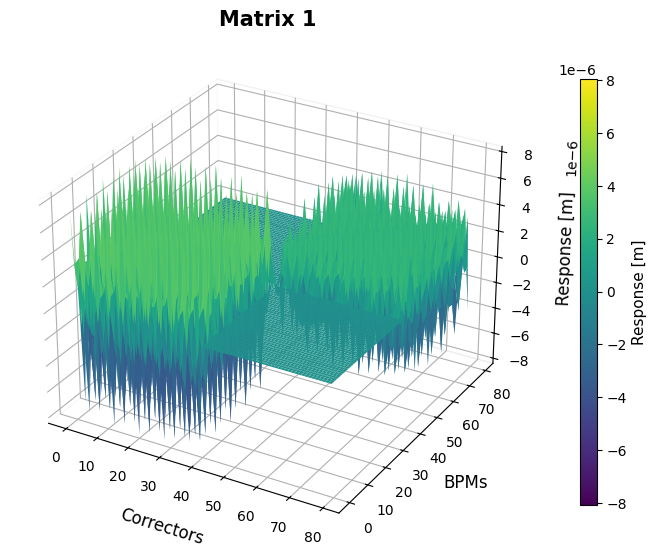

In [5]:
from pyLOCO.analysis import plot_matrices
from pyloco_config import FitInitConfig, RMConfig, fixed_parameters
from pyLOCO.response_matrix import response_matrix

FODO.disable_6d()

Corords = [cor_indices, cor_indices]

CMstep = [[1e-6] * len(Corords[0]), [1e-6] * len(Corords[1])]


fit_cfg = FitInitConfig()
includeDispersion = False
HCMCoupling = np.zeros(len(Corords[0]))
VCMCoupling = np.zeros(len(Corords[1]))

cfg = RMConfig(
    dkick=CMstep,
    bpm_ords=bpm_indices,
    cm_ords=Corords,
    HCMCoupling=HCMCoupling,
    VCMCoupling=VCMCoupling,
    rfStep=fixed_parameters.rfstep,
    includeDispersion=includeDispersion
)

# --- Compute model ORM ---

orm_model = response_matrix(FODO, config=cfg)

#rms_diff = np.sqrt(np.mean((orm_model - orm)**2))
plot_matrices(orm_model, titles=None, cmap='viridis', plot_type='3d')
#print(f"RMS difference between model and measured ORM: {rms_diff:.3e} m")

In [6]:
# ------------------------------------------------------------
# Make a copy of the ideal lattice
# ------------------------------------------------------------

FODO_error = copy.deepcopy(FODO)

print("Number of quadrupoles:", len(quads_indices))
print("Quadrupole indices:", quads_indices)

Number of quadrupoles: 40
Quadrupole indices: [  3   9  16  22  29  35  42  48  55  61  68  74  81  87  94 100 107 113
 120 126 133 139 146 152 159 165 172 178 185 191 198 204 211 217 224 230
 237 243 250 256]


In [7]:
# ------------------------------------------------------------
# We will intoduce some errors to the quadrupoles (Calibration Erros)
# ------------------------------------------------------------

# ------------------------------------------------------------
# Choose some quadrupoles to modify
# ------------------------------------------------------------

# Here we modify 5 quadrupoles
selected_quads = quads_indices[[2, 9, 16, 29, 33, 39]]

print("\nSelected quadrupoles:")
print(selected_quads)


# ------------------------------------------------------------
# Define relative strength errors
# ------------------------------------------------------------


relative_errors = np.array([
    +0.01,    # +1 %
    -0.015,   # -1.5 %
    +0.02,    # +2 %
    -0.01,    # -1 %
    +0.015,   # +1.5 %
])


# ------------------------------------------------------------
# Apply the errors
# ------------------------------------------------------------

applied_delta_k = []

for idx, rel_error in zip(selected_quads, relative_errors):

    k_old = FODO_error[idx].K

    delta_k = rel_error * k_old

    k_new = k_old + delta_k

    FODO_error[idx].K = k_new

    applied_delta_k.append(delta_k)

    print(
        f"{FODO_error[idx].FamName:5s} "
        f"index = {idx:3d} | "
        f"K0 = {k_old:+.6f} | "
        f"dK = {delta_k:+.6f} | "
        f"Knew = {k_new:+.6f}"
    )

applied_delta_k = np.asarray(applied_delta_k)


Selected quadrupoles:
[ 16  61 107 191 217 256]
QF    index =  16 | K0 = +1.182981 | dK = +0.011830 | Knew = +1.194811
QD    index =  61 | K0 = -1.170449 | dK = +0.017557 | Knew = -1.152893
QF    index = 107 | K0 = +1.182981 | dK = +0.023660 | Knew = +1.206641
QD    index = 191 | K0 = -1.170449 | dK = +0.011704 | Knew = -1.158745
QD    index = 217 | K0 = -1.170449 | dK = -0.017557 | Knew = -1.188006


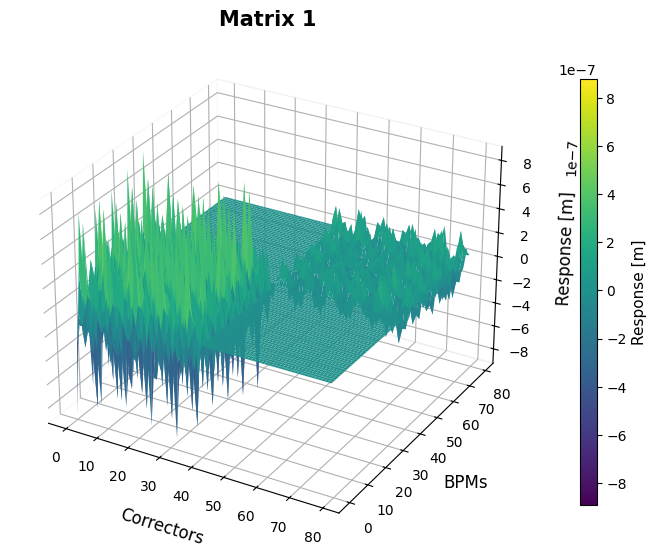

RMS difference between model and measured ORM: 1.440e-07 m


In [8]:
orm_model_error = response_matrix(FODO_error, config=cfg)

rms_diff = np.sqrt(np.mean((orm_model - orm_model_error)**2))
plot_matrices(orm_model_error - orm_model, titles=None, cmap='viridis', plot_type='3d')
print(f"RMS difference between model and measured ORM: {rms_diff:.3e} m")


Tune AFTER errors:
  Qx = 0.161692
  Qy = 0.743808


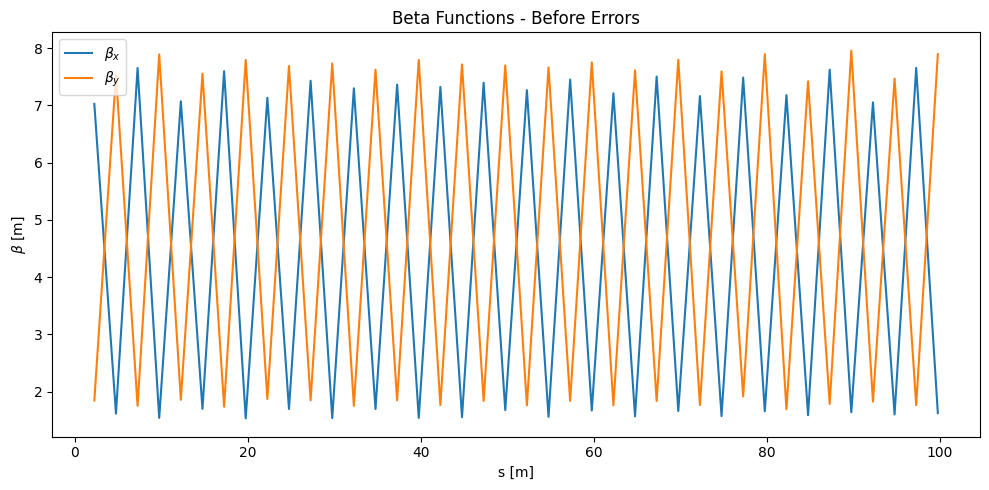

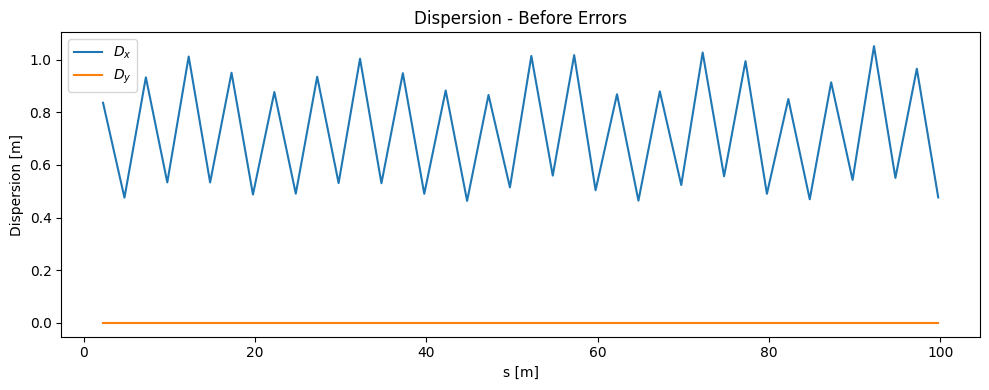

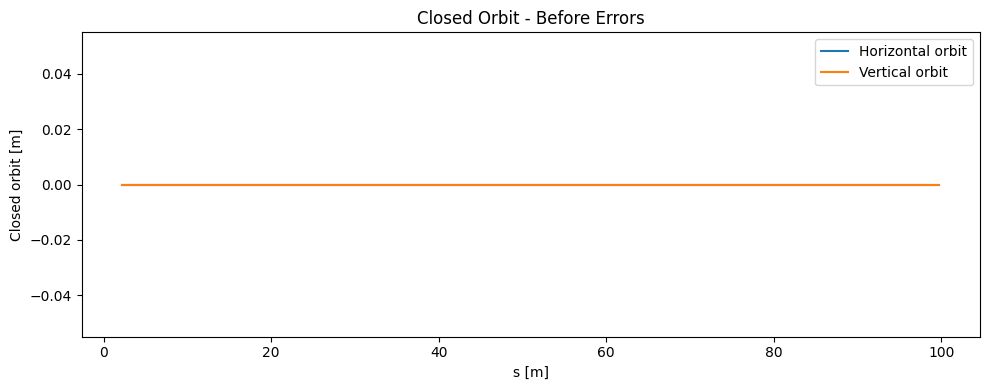

In [9]:
# ============================================================
# OPTICS AFTER QUADRUPOLE ERRORS
# ============================================================

lindata0_after, ringdata_after, lindata_after = at.get_optics(
    FODO_error,
    refpts=bpm_indices
)


# ------------------------------------------------------------
# Global optics parameters
# ------------------------------------------------------------

tune_after = ringdata_after.tune

print("\nTune AFTER errors:")
print(f"  Qx = {tune_after[0]:.6f}")
print(f"  Qy = {tune_after[1]:.6f}")


# ------------------------------------------------------------
# Extract optics
# ------------------------------------------------------------

s_after = lindata_after.s_pos

beta_x_after = lindata_after.beta[:, 0]
beta_y_after = lindata_after.beta[:, 1]

disp_x_after = lindata_after.dispersion[:, 0]
disp_y_after = lindata_after.dispersion[:, 2]

x_orbit_after = lindata_after.closed_orbit[:, 0]
y_orbit_after = lindata_after.closed_orbit[:, 2]


# ------------------------------------------------------------
# Plot beta functions BEFORE
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(s_after, beta_x_after, label=r"$\beta_x$")
plt.plot(s_after, beta_y_after, label=r"$\beta_y$")

plt.xlabel("s [m]")
plt.ylabel(r"$\beta$ [m]")
plt.title("Beta Functions - Before Errors")
plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot dispersion BEFORE
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(s_after, disp_x_after, label=r"$D_x$")
plt.plot(s_after, disp_y_after, label=r"$D_y$")

plt.xlabel("s [m]")
plt.ylabel("Dispersion [m]")
plt.title("Dispersion - Before Errors")
plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot orbit BEFORE
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(s_after, x_orbit_after, label="Horizontal orbit")
plt.plot(s_after, y_orbit_after, label="Vertical orbit")

plt.xlabel("s [m]")
plt.ylabel("Closed orbit [m]")
plt.title("Closed Orbit - Before Errors")
plt.legend()

plt.tight_layout()
plt.show()

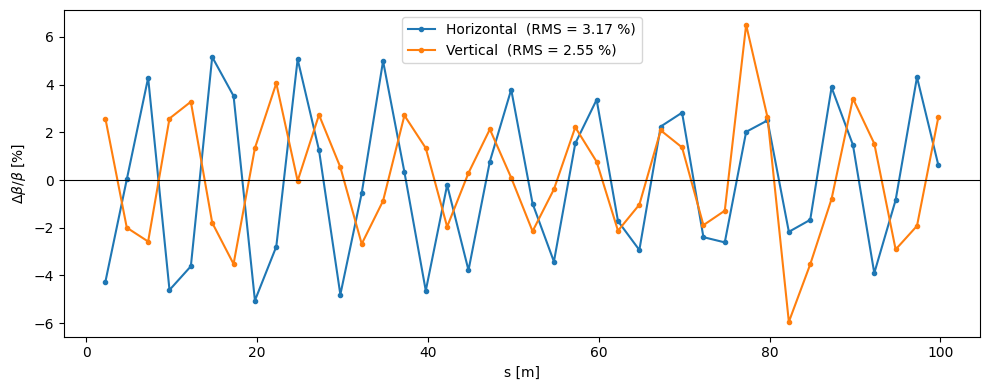

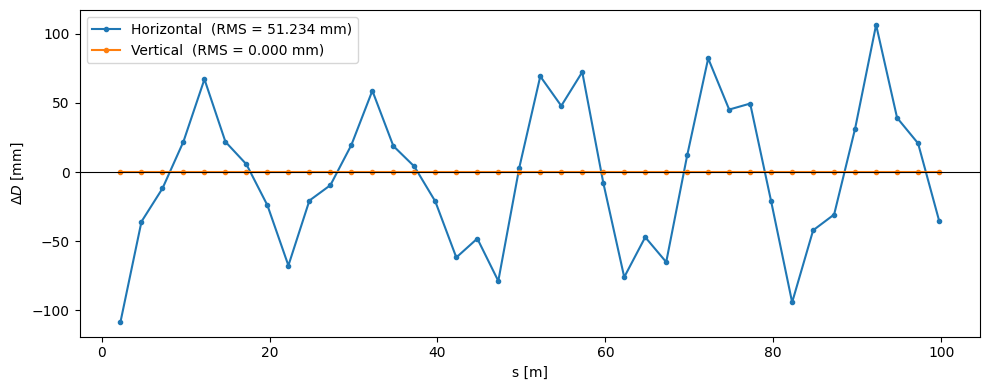

Optics errors:
Beta beating RMS: Horizontal = 3.173 %, Vertical = 2.548 %
Dispersion error RMS: Horizontal = 51.234 mm, Vertical = 0.000 mm

Tune shift:
ΔQx = +1.169173e-02
ΔQy = -6.192073e-03


In [10]:
# ============================================================
# CALCULATE OPTICS ERRORS
# ============================================================

# ------------------------------------------------------------
# Beta beating [%]
# ------------------------------------------------------------

beta_x_error = (
    (beta_x_after - beta_x_before)
    / beta_x_before
) * 100

beta_y_error = (
    (beta_y_after - beta_y_before)
    / beta_y_before
) * 100


# ------------------------------------------------------------
# Dispersion error [mm]
# ------------------------------------------------------------

disp_x_error = (
    disp_x_after - disp_x_before
) * 1e3

disp_y_error = (
    disp_y_after - disp_y_before
) * 1e3


# ------------------------------------------------------------
# Closed orbit difference [mm]
# ------------------------------------------------------------

x_orbit_error = (
    x_orbit_after - x_orbit_before
) * 1e3

y_orbit_error = (
    y_orbit_after - y_orbit_before
) * 1e3


# ------------------------------------------------------------
# Tune shift
# ------------------------------------------------------------

delta_qx = tune_after[0] - tune_before[0]
delta_qy = tune_after[1] - tune_before[1]

# ------------------------------------------------------------
# RMS of the Beta Beating
# ------------------------------------------------------------

beta_x_rms = np.sqrt(np.mean(beta_x_error**2))
beta_y_rms = np.sqrt(np.mean(beta_y_error**2))


plt.figure(figsize=(10, 4))

plt.plot(
    s_before,
    beta_x_error,
    "-o",
    markersize=3,
    label=rf"Horizontal  (RMS = {beta_x_rms:.2f} %)"
)

plt.plot(
    s_before,
    beta_y_error,
    "-o",
    markersize=3,
    label=rf"Vertical  (RMS = {beta_y_rms:.2f} %)"
)

plt.axhline(
    0,
    linewidth=0.8,
    color="black"
)

plt.xlabel("s [m]")
plt.ylabel(r"$\Delta\beta/\beta$ [%]")

plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# DISPERSION ERROR
# ============================================================

disp_x_rms = np.sqrt(np.mean(disp_x_error**2))
disp_y_rms = np.sqrt(np.mean(disp_y_error**2))


plt.figure(figsize=(10, 4))

plt.plot(
    s_before,
    disp_x_error,
    "-o",
    markersize=3,
    label=rf"Horizontal  (RMS = {disp_x_rms:.3f} mm)"
)

plt.plot(
    s_before,
    disp_y_error,
    "-o",
    markersize=3,
    label=rf"Vertical  (RMS = {disp_y_rms:.3f} mm)"
)

plt.axhline(
    0,
    linewidth=0.8,
    color="black"
)

plt.xlabel("s [m]")
plt.ylabel(r"$\Delta D$ [mm]")

plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# PRINT SUMMARY
# ============================================================

print("Optics errors:")
print(
    f"Beta beating RMS: "
    f"Horizontal = {beta_x_rms:.3f} %, "
    f"Vertical = {beta_y_rms:.3f} %"
)

print(
    f"Dispersion error RMS: "
    f"Horizontal = {disp_x_rms:.3f} mm, "
    f"Vertical = {disp_y_rms:.3f} mm"
)

print("\nTune shift:")
print(f"ΔQx = {delta_qx:+.6e}")
print(f"ΔQy = {delta_qy:+.6e}")


In [11]:
# ============================================================
# ORM FUNCTION
# ============================================================

def calculate_orm(
    ring,
    bpm_indices,
    cor_indices,
    dkick=1e-5
):
    """
    Calculate the full 2-plane orbit response matrix.

    Output structure:

                 H correctors       V correctors

    x BPMs            XX                 XY

    y BPMs            YX                 YY
    """

    nbpm = len(bpm_indices)
    ncor = len(cor_indices)

    ORM = np.zeros(
        (2 * nbpm, 2 * ncor)
    )

    # --------------------------------------------------------
    # Horizontal correctors
    # --------------------------------------------------------

    for j, cor in enumerate(cor_indices):

        ring_plus = copy.deepcopy(ring)
        ring_minus = copy.deepcopy(ring)

        ring_plus[cor].KickAngle[0] += dkick
        ring_minus[cor].KickAngle[0] -= dkick

        _, _, optics_plus = at.get_optics(
            ring_plus,
            refpts=bpm_indices
        )

        _, _, optics_minus = at.get_optics(
            ring_minus,
            refpts=bpm_indices
        )

        x_plus = optics_plus.closed_orbit[:, 0]
        y_plus = optics_plus.closed_orbit[:, 2]

        x_minus = optics_minus.closed_orbit[:, 0]
        y_minus = optics_minus.closed_orbit[:, 2]

        dx = (x_plus - x_minus) / (2 * dkick)
        dy = (y_plus - y_minus) / (2 * dkick)

        # XX
        ORM[:nbpm, j] = dx

        # YX
        ORM[nbpm:, j] = dy

    # --------------------------------------------------------
    # Vertical correctors
    # --------------------------------------------------------

    for j, cor in enumerate(cor_indices):

        ring_plus = copy.deepcopy(ring)
        ring_minus = copy.deepcopy(ring)

        ring_plus[cor].KickAngle[1] += dkick
        ring_minus[cor].KickAngle[1] -= dkick

        _, _, optics_plus = at.get_optics(
            ring_plus,
            refpts=bpm_indices
        )

        _, _, optics_minus = at.get_optics(
            ring_minus,
            refpts=bpm_indices
        )

        x_plus = optics_plus.closed_orbit[:, 0]
        y_plus = optics_plus.closed_orbit[:, 2]

        x_minus = optics_minus.closed_orbit[:, 0]
        y_minus = optics_minus.closed_orbit[:, 2]

        dx = (x_plus - x_minus) / (2 * dkick)
        dy = (y_plus - y_minus) / (2 * dkick)

        # XY
        ORM[:nbpm, ncor + j] = dx

        # YY
        ORM[nbpm:, ncor + j] = dy

    return ORM


# ============================================================
# JACOBIAN FUNCTION
# ============================================================

def calculate_quad_jacobian(
    ring,
    bpm_indices,
    cor_indices,
    fit_quad_indices,
    delta_k=1e-4
):

    orm0 = calculate_orm(
        ring,
        bpm_indices,
        cor_indices
    )

    ndata = orm0.size
    nquads = len(fit_quad_indices)

    J = np.zeros(
        (ndata, nquads)
    )

    for j, qidx in enumerate(fit_quad_indices):

        print(
            f"Jacobian: quadrupole "
            f"{j+1}/{nquads}"
        )

        ring_plus = copy.deepcopy(ring)
        ring_minus = copy.deepcopy(ring)

        ring_plus[qidx].K += delta_k
        ring_minus[qidx].K -= delta_k

        orm_plus = calculate_orm(
            ring_plus,
            bpm_indices,
            cor_indices
        )

        orm_minus = calculate_orm(
            ring_minus,
            bpm_indices,
            cor_indices
        )

        derivative = (
            orm_plus - orm_minus
        ) / (2 * delta_k)

        J[:, j] = derivative.ravel()

    return J

# ORM_measured​−ORM_model​=JΔK

In [ ]:
# ============================================================
# MODEL AND MEASURED ORM
# ============================================================

ORM_model_before = calculate_orm(
    FODO,
    bpm_indices,
    cor_indices
)

ORM_measured = calculate_orm(
    FODO_error,
    bpm_indices,
    cor_indices
)


print("ORM shape:", ORM_measured.shape)

orm_difference_before = (
    ORM_measured - ORM_model_before
)

orm_rms_before = np.sqrt(
    np.mean(orm_difference_before**2)
)

print(
    "ORM RMS difference before LOCO =",
    f"{orm_rms_before:.6e} m/rad"
)

ORM shape: (80, 80)
ORM RMS difference before LOCO = 1.440135e-01 m/rad


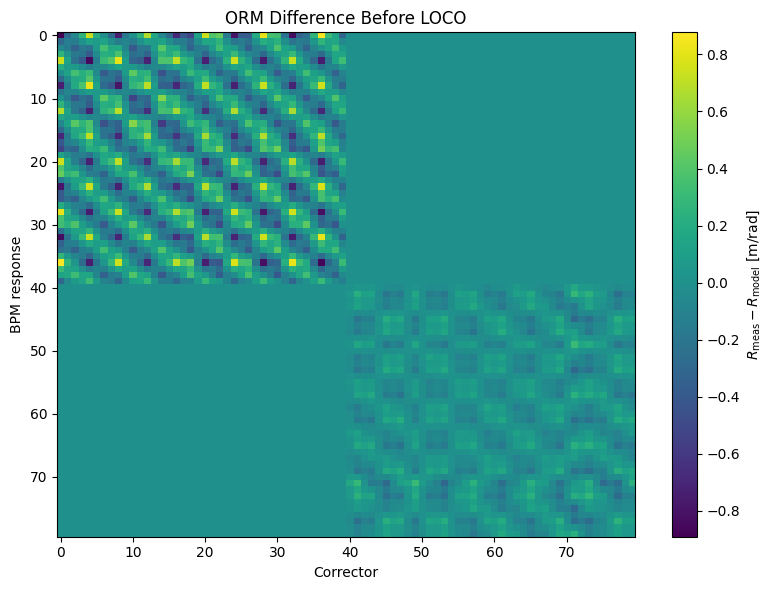

In [13]:
plt.figure(figsize=(8, 6))

plt.imshow(
    ORM_measured - ORM_model_before,
    aspect="auto"
)

plt.colorbar(
    label=r"$R_{\mathrm{meas}}-R_{\mathrm{model}}$ [m/rad]"
)

plt.xlabel("Corrector")
plt.ylabel("BPM response")

plt.title("ORM Difference Before LOCO")

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# 4. JACOBIAN FUNCTION
# ============================================================

def calculate_quad_jacobian(
    ring,
    bpm_indices,
    cor_indices,
    fit_quad_indices,
    delta_k=1e-4
):

    orm0 = calculate_orm(
        ring,
        bpm_indices,
        cor_indices
    )

    ndata = orm0.size
    nquads = len(fit_quad_indices)

    J = np.zeros(
        (ndata, nquads)
    )

    for j, qidx in enumerate(fit_quad_indices):

        print(
            f"Jacobian: quadrupole "
            f"{j+1}/{nquads}"
        )

        ring_plus = copy.deepcopy(ring)
        ring_minus = copy.deepcopy(ring)

        ring_plus[qidx].K += delta_k
        ring_minus[qidx].K -= delta_k

        orm_plus = calculate_orm(
            ring_plus,
            bpm_indices,
            cor_indices
        )

        orm_minus = calculate_orm(
            ring_minus,
            bpm_indices,
            cor_indices
        )

        derivative = (
            orm_plus - orm_minus
        ) / (2 * delta_k)

        J[:, j] = derivative.ravel()

    return J

In [15]:
selected_quads = quads_indices[[2, 9, 16, 29, 33, 39]]
# ============================================================
# PARAMETERS TO FIT
# ============================================================

fit_quad_indices = selected_quads.copy()

print(
    "Fitting quadrupoles:",
    fit_quad_indices
)

Fitting quadrupoles: [ 16  61 107 191 217 256]


In [16]:
# ============================================================
# SIMPLE LOCO FIT
# ============================================================

loco_ring = copy.deepcopy(FODO)

n_iterations = 5

chi2_history = []

fitted_total_delta_k = np.zeros(
    len(fit_quad_indices)
)


for iteration in range(n_iterations):

    print("\n")
    print("=" * 60)
    print(f"LOCO iteration {iteration + 1}")
    print("=" * 60)

    # --------------------------------------------------------
    # Current model ORM
    # --------------------------------------------------------

    ORM_model = calculate_orm(
        loco_ring,
        bpm_indices,
        cor_indices
    )

    # --------------------------------------------------------
    # Residual
    # measured - model
    # --------------------------------------------------------

    residual_matrix = (
        ORM_measured - ORM_model
    )

    residual = residual_matrix.ravel()

    rms = np.sqrt(
        np.mean(residual**2)
    )

    chi2_history.append(rms)

    print(
        f"ORM RMS residual = {rms:.6e}"
    )

    # --------------------------------------------------------
    # Calculate Jacobian
    # --------------------------------------------------------

    J = calculate_quad_jacobian(
        loco_ring,
        bpm_indices,
        cor_indices,
        fit_quad_indices,
        delta_k=1e-4
    )

    # --------------------------------------------------------
    # Solve
    #
    #       J deltaK = Rmeasured - Rmodel
    #
    # --------------------------------------------------------

    delta_k_fit, _, _, singular_values = np.linalg.lstsq(
        J,
        residual,
        rcond=1e-8
    )

    print("\nQuadrupole correction this iteration:")

    for qidx, dk in zip(
        fit_quad_indices,
        delta_k_fit
    ):

        print(
            f"quad {qidx:3d}: "
            f"dK = {dk:+.6e}"
        )

    # --------------------------------------------------------
    # Update model
    # --------------------------------------------------------

    for j, qidx in enumerate(
        fit_quad_indices
    ):

        loco_ring[qidx].K += delta_k_fit[j]

    fitted_total_delta_k += delta_k_fit



LOCO iteration 1
ORM RMS residual = 1.440135e-01
Jacobian: quadrupole 1/6
Jacobian: quadrupole 2/6
Jacobian: quadrupole 3/6
Jacobian: quadrupole 4/6
Jacobian: quadrupole 5/6
Jacobian: quadrupole 6/6

Quadrupole correction this iteration:
quad  16: dK = +1.128250e-02
quad  61: dK = +1.705893e-02
quad 107: dK = +2.159535e-02
quad 191: dK = +1.144187e-02
quad 217: dK = -1.687531e-02
quad 256: dK = +4.539234e-05


LOCO iteration 2
ORM RMS residual = 9.736660e-03
Jacobian: quadrupole 1/6
Jacobian: quadrupole 2/6
Jacobian: quadrupole 3/6
Jacobian: quadrupole 4/6
Jacobian: quadrupole 5/6
Jacobian: quadrupole 6/6

Quadrupole correction this iteration:
quad  16: dK = +5.461578e-04
quad  61: dK = +4.979985e-04
quad 107: dK = +2.049512e-03
quad 191: dK = +2.631542e-04
quad 217: dK = -6.806330e-04
quad 256: dK = -4.501975e-05


LOCO iteration 3
ORM RMS residual = 6.498784e-05
Jacobian: quadrupole 1/6
Jacobian: quadrupole 2/6
Jacobian: quadrupole 3/6
Jacobian: quadrupole 4/6
Jacobian: quadrupole 

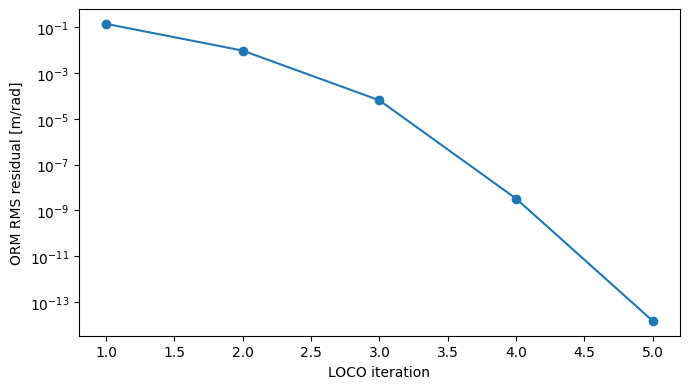

In [17]:
# ============================================================
# LOCO CONVERGENCE
# ============================================================

plt.figure(figsize=(7, 4))

plt.semilogy(
    np.arange(1, len(chi2_history) + 1),
    chi2_history,
    "-o"
)

plt.xlabel("LOCO iteration")
plt.ylabel("ORM RMS residual [m/rad]")

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# 8. TRUE QUADRUPOLE ERRORS
# ============================================================

true_delta_k = np.array([
    FODO_error[idx].K - FODO[idx].K
    for idx in fit_quad_indices
])


print("\nTrue vs fitted quadrupole errors")
print("-" * 60)

for qidx, true_dk, fit_dk in zip(
    fit_quad_indices,
    true_delta_k,
    fitted_total_delta_k
):

    print(
        f"quad {qidx:3d}: "
        f"true = {true_dk:+.6e}   "
        f"fit = {fit_dk:+.6e}"
    )


True vs fitted quadrupole errors
------------------------------------------------------------
quad  16: true = +1.182981e-02   fit = +1.182981e-02
quad  61: true = +1.755674e-02   fit = +1.755674e-02
quad 107: true = +2.365962e-02   fit = +2.365962e-02
quad 191: true = +1.170449e-02   fit = +1.170449e-02
quad 217: true = -1.755674e-02   fit = -1.755674e-02
quad 256: true = +0.000000e+00   fit = +1.192784e-15


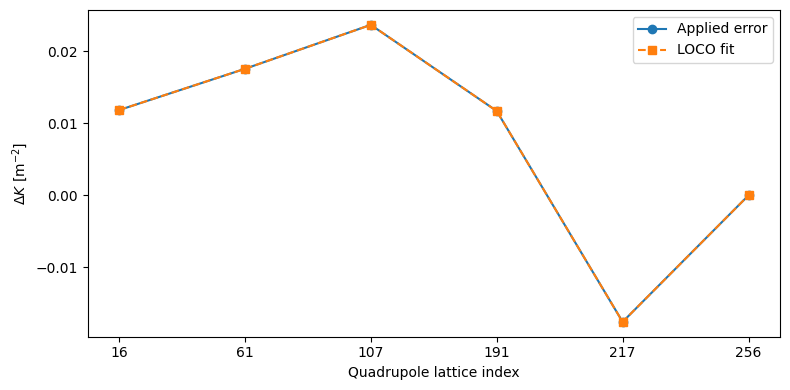

In [19]:
# ============================================================
# 9. TRUE vs LOCO-FITTED QUADRUPOLE ERRORS
# ============================================================

x = np.arange(
    len(fit_quad_indices)
)

plt.figure(figsize=(8, 4))

plt.plot(
    x,
    true_delta_k,
    "o-",
    label="Applied error"
)

plt.plot(
    x,
    fitted_total_delta_k,
    "s--",
    label="LOCO fit"
)

plt.xticks(
    x,
    [str(i) for i in fit_quad_indices]
)

plt.xlabel("Quadrupole lattice index")
plt.ylabel(r"$\Delta K$ [m$^{-2}$]")

plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# 10. ORM AFTER LOCO
# ============================================================

ORM_model_after = calculate_orm(
    loco_ring,
    bpm_indices,
    cor_indices
)


orm_difference_after = (
    ORM_measured - ORM_model_after
)


orm_rms_after = np.sqrt(
    np.mean(orm_difference_after**2)
)


print("\nORM comparison:")
print(
    f"Before LOCO : {orm_rms_before:.6e}"
)

print(
    f"After LOCO  : {orm_rms_after:.6e}"
)


ORM comparison:
Before LOCO : 1.440135e-01
After LOCO  : 1.492271e-14


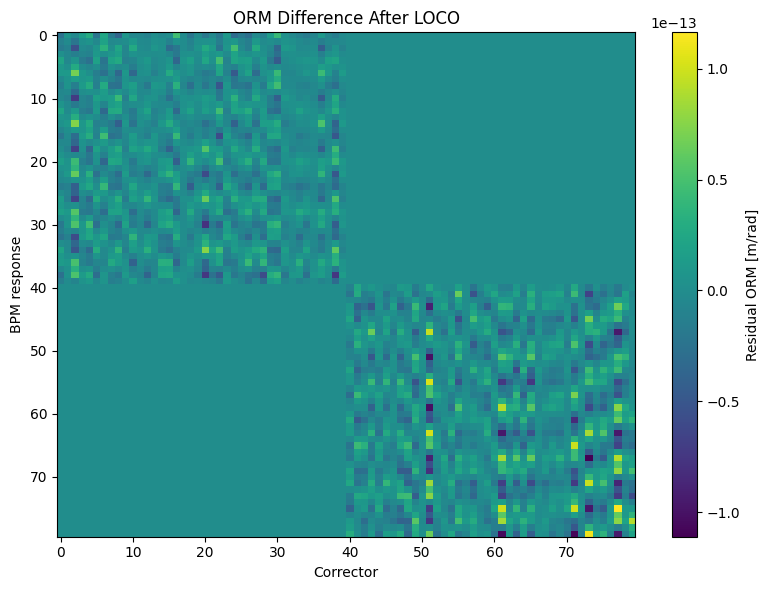

In [21]:
plt.figure(figsize=(8, 6))

plt.imshow(
    ORM_measured - ORM_model_after,
    aspect="auto"
)

plt.colorbar(
    label="Residual ORM [m/rad]"
)

plt.xlabel("Corrector")
plt.ylabel("BPM response")

plt.title("ORM Difference After LOCO")

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# 11. OPTICS AFTER LOCO
# ============================================================

_, ringdata_loco, lindata_loco = at.get_optics(
    loco_ring,
    refpts=bpm_indices
)

beta_x_loco = lindata_loco.beta[:, 0]
beta_y_loco = lindata_loco.beta[:, 1]

disp_x_loco = lindata_loco.dispersion[:, 0]
disp_y_loco = lindata_loco.dispersion[:, 2]

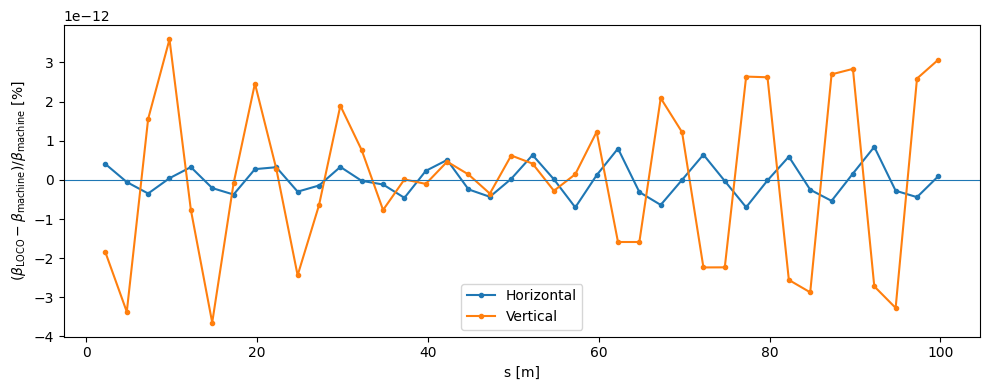

In [23]:
beta_x_residual = (
    (beta_x_loco - beta_x_after)
    / beta_x_after
) * 100

beta_y_residual = (
    (beta_y_loco - beta_y_after)
    / beta_y_after
) * 100


plt.figure(figsize=(10, 4))

plt.plot(
    s_after,
    beta_x_residual,
    "-o",
    markersize=3,
    label="Horizontal"
)

plt.plot(
    s_after,
    beta_y_residual,
    "-o",
    markersize=3,
    label="Vertical"
)

plt.axhline(
    0,
    linewidth=0.8
)

plt.xlabel("s [m]")
plt.ylabel(
    r"$(\beta_{\rm LOCO}-\beta_{\rm machine})/"
    r"\beta_{\rm machine}$ [%]"
)

plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# 1. APPLY LOCO CORRECTION TO THE ERROR LATTICE
# ============================================================

import copy
import numpy as np
import matplotlib.pyplot as plt

FODO_corrected = copy.deepcopy(FODO_error)

print("Applying LOCO correction")
print("=" * 65)

for qidx, dk_fit in zip(
    fit_quad_indices,
    fitted_total_delta_k
):
    k_before_correction = FODO_corrected[qidx].K

    # LOCO estimated the error, so correction is -dK_fit
    FODO_corrected[qidx].K -= dk_fit

    k_after_correction = FODO_corrected[qidx].K

    print(
        f"Quad {qidx:3d}: "
        f"K = {k_before_correction:+.6f}  ->  "
        f"{k_after_correction:+.6f}   "
        f"correction = {-dk_fit:+.6e}"
    )

Applying LOCO correction
Quad  16: K = +1.194811  ->  +1.182981   correction = -1.182981e-02
Quad  61: K = -1.152893  ->  -1.170449   correction = -1.755674e-02
Quad 107: K = +1.206641  ->  +1.182981   correction = -2.365962e-02
Quad 191: K = -1.158745  ->  -1.170449   correction = -1.170449e-02
Quad 217: K = -1.188006  ->  -1.170449   correction = +1.755674e-02
Quad 256: K = -1.170449  ->  -1.170449   correction = -1.192784e-15


In [26]:
# ============================================================
# 2. CALCULATE OPTICS AFTER LOCO CORRECTION
# ============================================================

lindata0_corrected, ringdata_corrected, lindata_corrected = at.get_optics(
    FODO_corrected,
    refpts=bpm_indices
)

tune_corrected = ringdata_corrected.tune

s_corrected = lindata_corrected.s_pos

beta_x_corrected = lindata_corrected.beta[:, 0]
beta_y_corrected = lindata_corrected.beta[:, 1]

disp_x_corrected = lindata_corrected.dispersion[:, 0]
disp_y_corrected = lindata_corrected.dispersion[:, 2]

x_orbit_corrected = lindata_corrected.closed_orbit[:, 0]
y_orbit_corrected = lindata_corrected.closed_orbit[:, 2]


print("\nTunes")
print("=" * 50)

print(
    f"Ideal       : "
    f"Qx = {tune_before[0]:.6f}, "
    f"Qy = {tune_before[1]:.6f}"
)

print(
    f"With errors : "
    f"Qx = {tune_after[0]:.6f}, "
    f"Qy = {tune_after[1]:.6f}"
)

print(
    f"After LOCO  : "
    f"Qx = {tune_corrected[0]:.6f}, "
    f"Qy = {tune_corrected[1]:.6f}"
)


Tunes
Ideal       : Qx = 0.150000, Qy = 0.750000
With errors : Qx = 0.161692, Qy = 0.743808
After LOCO  : Qx = 0.150000, Qy = 0.750000


In [27]:
# ============================================================
# 3. BETA BEATING
# ============================================================

# Before correction: error lattice vs ideal lattice
beta_x_error_before = (
    (beta_x_after - beta_x_before)
    / beta_x_before
) * 100

beta_y_error_before = (
    (beta_y_after - beta_y_before)
    / beta_y_before
) * 100


# After LOCO correction: corrected lattice vs ideal lattice
beta_x_error_corrected = (
    (beta_x_corrected - beta_x_before)
    / beta_x_before
) * 100

beta_y_error_corrected = (
    (beta_y_corrected - beta_y_before)
    / beta_y_before
) * 100


# RMS
bx_rms_before = np.sqrt(np.mean(beta_x_error_before**2))
by_rms_before = np.sqrt(np.mean(beta_y_error_before**2))

bx_rms_corrected = np.sqrt(np.mean(beta_x_error_corrected**2))
by_rms_corrected = np.sqrt(np.mean(beta_y_error_corrected**2))

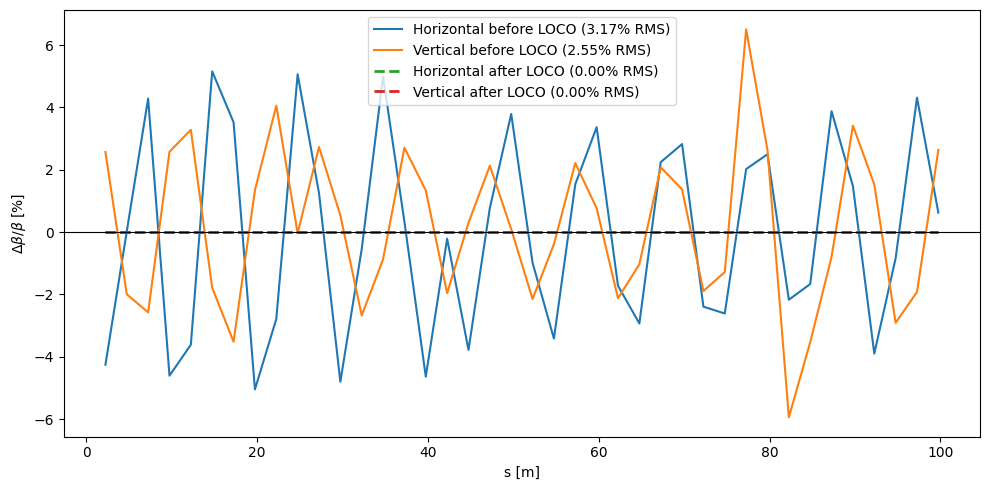

In [28]:
# ============================================================
# 4. PLOT BETA BEATING
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    s_before,
    beta_x_error_before,
    "-",
    label=rf"Horizontal before LOCO ({bx_rms_before:.2f}% RMS)"
)

plt.plot(
    s_before,
    beta_y_error_before,
    "-",
    label=rf"Vertical before LOCO ({by_rms_before:.2f}% RMS)"
)

plt.plot(
    s_before,
    beta_x_error_corrected,
    "--",
    linewidth=2,
    label=rf"Horizontal after LOCO ({bx_rms_corrected:.2f}% RMS)"
)

plt.plot(
    s_before,
    beta_y_error_corrected,
    "--",
    linewidth=2,
    label=rf"Vertical after LOCO ({by_rms_corrected:.2f}% RMS)"
)

plt.axhline(0, color="black", linewidth=0.8)

plt.xlabel("s [m]")
plt.ylabel(r"$\Delta\beta/\beta$ [%]")

plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# 5. DISPERSION ERROR
# ============================================================

# Before LOCO
disp_x_error_before = (
    disp_x_after - disp_x_before
) * 1e3

disp_y_error_before = (
    disp_y_after - disp_y_before
) * 1e3


# After LOCO
disp_x_error_corrected = (
    disp_x_corrected - disp_x_before
) * 1e3

disp_y_error_corrected = (
    disp_y_corrected - disp_y_before
) * 1e3


# RMS
dx_rms_before = np.sqrt(
    np.mean(disp_x_error_before**2)
)

dy_rms_before = np.sqrt(
    np.mean(disp_y_error_before**2)
)

dx_rms_corrected = np.sqrt(
    np.mean(disp_x_error_corrected**2)
)

dy_rms_corrected = np.sqrt(
    np.mean(disp_y_error_corrected**2)
)

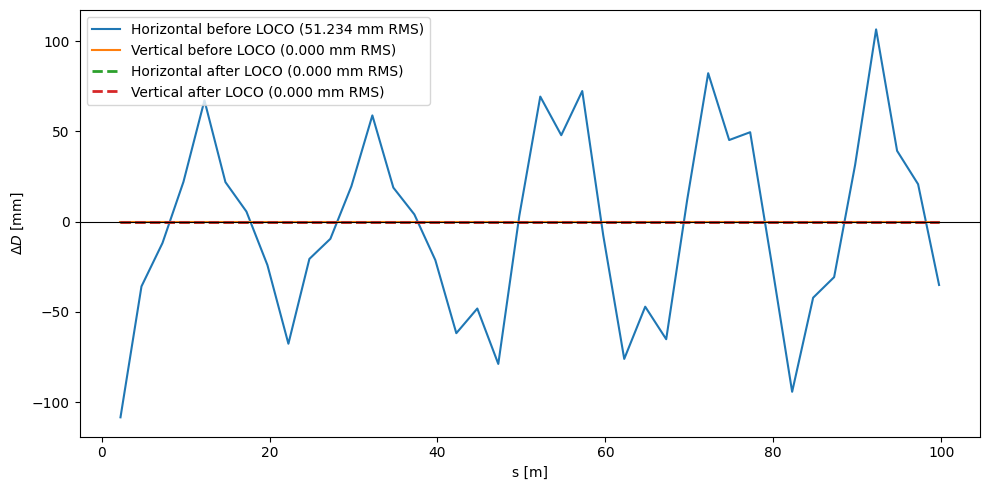

In [30]:
# ============================================================
# 6. PLOT DISPERSION ERROR
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    s_before,
    disp_x_error_before,
    "-",
    label=rf"Horizontal before LOCO ({dx_rms_before:.3f} mm RMS)"
)

plt.plot(
    s_before,
    disp_y_error_before,
    "-",
    label=rf"Vertical before LOCO ({dy_rms_before:.3f} mm RMS)"
)

plt.plot(
    s_before,
    disp_x_error_corrected,
    "--",
    linewidth=2,
    label=rf"Horizontal after LOCO ({dx_rms_corrected:.3f} mm RMS)"
)

plt.plot(
    s_before,
    disp_y_error_corrected,
    "--",
    linewidth=2,
    label=rf"Vertical after LOCO ({dy_rms_corrected:.3f} mm RMS)"
)

plt.axhline(0, color="black", linewidth=0.8)

plt.xlabel("s [m]")
plt.ylabel(r"$\Delta D$ [mm]")

plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# 7. SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("LOCO OPTICS CORRECTION SUMMARY")
print("=" * 60)

print("\nBeta beating RMS [%]")
print(
    f"Horizontal : {bx_rms_before:.3f} -> "
    f"{bx_rms_corrected:.3f}"
)
print(
    f"Vertical   : {by_rms_before:.3f} -> "
    f"{by_rms_corrected:.3f}"
)

print("\nDispersion error RMS [mm]")
print(
    f"Horizontal : {dx_rms_before:.3f} -> "
    f"{dx_rms_corrected:.3f}"
)
print(
    f"Vertical   : {dy_rms_before:.3f} -> "
    f"{dy_rms_corrected:.3f}"
)

print("\nTune")
print(
    f"Qx: ideal = {tune_before[0]:.6f}, "
    f"error = {tune_after[0]:.6f}, "
    f"corrected = {tune_corrected[0]:.6f}"
)
print(
    f"Qy: ideal = {tune_before[1]:.6f}, "
    f"error = {tune_after[1]:.6f}, "
    f"corrected = {tune_corrected[1]:.6f}"
)


LOCO OPTICS CORRECTION SUMMARY

Beta beating RMS [%]
Horizontal : 3.173 -> 0.000
Vertical   : 2.548 -> 0.000

Dispersion error RMS [mm]
Horizontal : 51.234 -> 0.000
Vertical   : 0.000 -> 0.000

Tune
Qx: ideal = 0.150000, error = 0.161692, corrected = 0.150000
Qy: ideal = 0.750000, error = 0.743808, corrected = 0.750000
